# 03 — Эксперименты

Таблица экспериментов: **Гипотеза → Как проверялось → Результат + метрики**

**Модели:** Random Forest, XGBoost, LightGBM, ансамбли  
**Метрика:** Weighted F1-score

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from src.preprocessing import feature_engineering, scale_features, TARGET_COL, NUMERIC_COLS
from src.modeling import evaluate_model, get_X_y, save_model, build_experiment_table

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Libraries loaded')

Libraries loaded


In [2]:
# Загружаем немасштабированные данные (без FE)
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

# Применяем feature engineering к train, запоминаем пороги
thresholds = {}
train_fe = feature_engineering(train, thresholds)
# Применяем к val/test с теми же порогами
val_fe   = feature_engineering(val, thresholds)
test_fe  = feature_engineering(test, thresholds)

print('Новые фичи добавлены.')

Новые фичи добавлены.


In [3]:
# Масштабируем с учётом новых числовых колонок (все числовые, включая новые)
extended_numeric = NUMERIC_COLS + ['academic_pressure_index', 'mental_health_score', 'lifestyle_balance', 
                                   'is_sleep_deprived', 'is_high_financial_stress']
train_sc, val_sc, test_sc, scaler = scale_features(train_fe, val_fe, test_fe, numeric_cols=extended_numeric)
joblib.dump(scaler, '../models/scaler_experiment.pkl')

X_train, y_train = get_X_y(train_sc)
X_val, y_val     = get_X_y(val_sc)
X_test, y_test   = get_X_y(test_sc)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')

Skipping scaling for binary columns: ['is_high_financial_stress', 'is_sleep_deprived']
Train: (105000, 39), Val: (22500, 39)


## Эксперимент 1: Random Forest (default)

**Гипотеза:** Ансамбль деревьев без настройки лучше одиночного Decision Tree  
**Как проверялось:** RandomForestClassifier дефолт, оценка на val  
**Ожидаемый результат:** Weighted F1 > baseline DT

In [4]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
rf_metrics = evaluate_model(rf, X_val, y_val, 'val')
rf_metrics.update({'model_name': 'RandomForest (default)', 'hypothesis': 'Ансамбль > одиночное дерево'})
all_results = [rf_metrics]
save_model(rf, '../models/rf_default.pkl')


=== VAL ===
  accuracy: 0.3317
  weighted_f1: 0.3315
  macro_f1: 0.3315
  roc_auc_ovr: 0.4972

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.34      0.34      7465
           1       0.33      0.34      0.34      7540
           2       0.33      0.31      0.32      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/rf_default.pkl


## Эксперимент 2: Random Forest (tuned)

**Гипотеза:** Ограничение глубины уменьшит overfitting  
**Как проверялось:** Подбор max_depth и min_samples_leaf  
**Ожидаемый результат:** Лучше RF default по Macro F1

In [5]:
rf_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5,
                                  max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)
rf_tuned.fit(X_train, y_train)
rf_tuned_metrics = evaluate_model(rf_tuned, X_val, y_val, 'val')
rf_tuned_metrics.update({'model_name': 'RandomForest (tuned)', 'hypothesis': 'Ограничение глубины'})
all_results.append(rf_tuned_metrics)
save_model(rf_tuned, '../models/rf_tuned.pkl')


=== VAL ===
  accuracy: 0.333
  weighted_f1: 0.3326
  macro_f1: 0.3326
  roc_auc_ovr: 0.4999

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.31      0.32      7465
           1       0.33      0.36      0.35      7540
           2       0.33      0.32      0.33      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/rf_tuned.pkl


## Эксперимент 2б: Систематический подбор гиперпараметров Random Forest (RandomizedSearchCV)

**Гипотеза:** Случайный поиск по сетке гиперпараметров найдёт лучшую комбинацию, чем ручной подбор  
**Как проверялось:** RandomizedSearchCV с 30 итерациями, 3-fold CV по Weighted F1  
**Ожидаемый результат:** Weighted F1 >= RF tuned (ручной)

In [6]:
from scipy.stats import randint, uniform

param_dist_rf = {
    'n_estimators': randint(100, 400),
    'max_depth': [10, 15, 20, 25, None],
    'min_samples_leaf': randint(1, 20),
    'max_features': ['sqrt', 'log2', 0.5],
    'min_samples_split': randint(2, 20),
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_search = RandomizedSearchCV(
    rf_base, param_distributions=param_dist_rf,
    n_iter=30, cv=3, scoring='f1_weighted',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
print('Лучшие параметры RF:', rf_search.best_params_)
print('CV F1 (best):', round(rf_search.best_score_, 4))

rf_best = rf_search.best_estimator_
rf_search_metrics = evaluate_model(rf_best, X_val, y_val, 'val')
rf_search_metrics.update({
    'model_name': 'RandomForest (RandomizedSearchCV)',
    'hypothesis': 'Случайный поиск гиперпараметров'
})
all_results.append(rf_search_metrics)
save_model(rf_best, '../models/rf_best.pkl')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Лучшие параметры RF: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 19, 'n_estimators': 188}
CV F1 (best): 0.3351

=== VAL ===
  accuracy: 0.3314
  weighted_f1: 0.331
  macro_f1: 0.331
  roc_auc_ovr: 0.4977

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.31      0.32      7465
           1       0.34      0.36      0.35      7540
           2       0.33      0.32      0.33      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/rf_best.pkl


## Эксперимент 3: XGBoost

**Гипотеза:** Gradient boosting точнее учится на остатках ошибок  
**Как проверялось:** XGBClassifier с early stopping на val  
**Ожидаемый результат:** Weighted F1 > Random Forest

In [7]:
xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                     eval_metric='mlogloss', early_stopping_rounds=20, verbosity=0)
xgb.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_metrics = evaluate_model(xgb, X_val, y_val, 'val')
xgb_metrics.update({'model_name': 'XGBoost', 'hypothesis': 'Бустинг лучше RF'})
all_results.append(xgb_metrics)
save_model(xgb, '../models/xgboost.pkl')


=== VAL ===
  accuracy: 0.333
  weighted_f1: 0.2671
  macro_f1: 0.2666
  roc_auc_ovr: 0.5054

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.08      0.13      7465
           1       0.33      0.77      0.47      7540
           2       0.33      0.15      0.20      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.27     22500
weighted avg       0.33      0.33      0.27     22500

Model saved to ../models/xgboost.pkl


## Эксперимент 4: LightGBM

**Гипотеза:** LightGBM быстрее XGBoost на 150k строк и не хуже по качеству  
**Как проверялось:** LGBMClassifier с leaf-wise growth + early stopping  
**Ожидаемый результат:** F1 >= XGBoost, время обучения меньше

In [8]:
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                       subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                       n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train, eval_set=[(X_val, y_val)],
         callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(period=-1)])
lgbm_metrics = evaluate_model(lgbm, X_val, y_val, 'val')
lgbm_metrics.update({'model_name': 'LightGBM', 'hypothesis': 'Leaf-wise быстрее XGBoost'})
all_results.append(lgbm_metrics)
save_model(lgbm, '../models/lgbm.pkl')


=== VAL ===
  accuracy: 0.3348
  weighted_f1: 0.2205
  macro_f1: 0.2197
  roc_auc_ovr: 0.5002

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.03      0.05      7465
           1       0.34      0.90      0.49      7540
           2       0.33      0.07      0.12      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.22     22500
weighted avg       0.33      0.33      0.22     22500

Model saved to ../models/lgbm.pkl


## Эксперимент 4б: GridSearchCV для LightGBM

**Гипотеза:** Точный перебор ключевых гиперпараметров LightGBM улучшит качество  
**Как проверялось:** GridSearchCV по num_leaves и learning_rate (3-fold CV)  
**Ожидаемый результат:** Weighted F1 >= LightGBM с дефолтными параметрами

In [9]:
param_grid_lgbm = {
    'num_leaves': [31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 400],
    'min_child_samples': [10, 20, 50],
}

lgbm_base = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                           subsample=0.8, colsample_bytree=0.8)
lgbm_grid = GridSearchCV(
    lgbm_base, param_grid=param_grid_lgbm,
    cv=3, scoring='f1_weighted', n_jobs=-1, verbose=1
)
lgbm_grid.fit(X_train, y_train)
print('Лучшие параметры LGBM:', lgbm_grid.best_params_)
print('CV F1 (best):', round(lgbm_grid.best_score_, 4))

lgbm_best = lgbm_grid.best_estimator_
lgbm_grid_metrics = evaluate_model(lgbm_best, X_val, y_val, 'val')
lgbm_grid_metrics.update({
    'model_name': 'LightGBM (GridSearchCV)',
    'hypothesis': 'Точный перебор num_leaves и learning_rate'
})
all_results.append(lgbm_grid_metrics)
save_model(lgbm_best, '../models/lgbm_best.pkl')

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Лучшие параметры LGBM: {'learning_rate': 0.1, 'min_child_samples': 10, 'n_estimators': 200, 'num_leaves': 127}
CV F1 (best): 0.336

=== VAL ===
  accuracy: 0.33
  weighted_f1: 0.3298
  macro_f1: 0.3298
  roc_auc_ovr: 0.4987

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.32      0.32      7465
           1       0.33      0.35      0.34      7540
           2       0.33      0.32      0.32      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Model saved to ../models/lgbm_best.pkl


## Эксперимент 5: PCA + LightGBM

**Гипотеза:** PCA убирает шум от коррелированных фичей  
**Как проверялось:** PCA(95% дисперсии) -> LightGBM  
**Ожидаемый результат:** Сравниваем с LightGBM без PCA

In [10]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
joblib.dump(pca, '../models/pca.pkl')
X_train_pca = pd.DataFrame(X_train_pca, columns=[f'PC{i+1}' for i in range(X_train_pca.shape[1])])
X_val_pca = pd.DataFrame(X_val_pca, columns=[f'PC{i+1}' for i in range(X_val_pca.shape[1])])
lgbm_pca = LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgbm_pca.fit(X_train_pca, y_train)
save_model(lgbm_pca, '../models/lgbm_pca.pkl')
y_pred_pca = lgbm_pca.predict(X_val_pca)
pca_metrics = {
    'model_name': 'LightGBM + PCA(95%)',
    'hypothesis': 'Удаление шума через PCA',
    'split': 'val',
    'accuracy': round(accuracy_score(y_val, y_pred_pca), 4),
    'weighted_f1': round(f1_score(y_val, y_pred_pca, average='weighted'), 4),
    'macro_f1': round(f1_score(y_val, y_pred_pca, average='macro'), 4),
}
all_results.append(pca_metrics)

Model saved to ../models/lgbm_pca.pkl


## Эксперимент 6: Voting Ensemble

**Гипотеза:** Soft voting усредняет ошибки разных алгоритмов  
**Как проверялось:** VotingClassifier(RF_tuned + XGBoost + LightGBM)  
**Ожидаемый результат:** F1 >= max отдельных моделей

In [11]:
rf_b = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=5,
                              max_features='sqrt', random_state=RANDOM_STATE, n_jobs=-1)
xgb_b = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                       subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                       eval_metric='mlogloss', verbosity=0)
lgbm_b = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                         subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                         n_jobs=-1, verbose=-1)

rf_b.fit(X_train, y_train)
xgb_b.fit(X_train, y_train)
lgbm_b.fit(X_train, y_train)

voting = VotingClassifier(estimators=[('rf', rf_b), ('xgb', xgb_b), ('lgbm', lgbm_b)],
                           voting='soft', n_jobs=-1)
voting.fit(X_train, y_train)

voting_metrics = evaluate_model(voting, X_val, y_val, 'val')
voting_metrics.update({'model_name': 'Voting (RF+XGB+LGBM)', 'hypothesis': 'Soft voting'})
all_results.append(voting_metrics)
save_model(voting, '../models/voting_ensemble.pkl')


=== VAL ===
  accuracy: 0.337
  weighted_f1: 0.3366
  macro_f1: 0.3366
  roc_auc_ovr: 0.5016

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.33      0.33      7465
           1       0.34      0.37      0.35      7540
           2       0.34      0.31      0.33      7495

    accuracy                           0.34     22500
   macro avg       0.34      0.34      0.34     22500
weighted avg       0.34      0.34      0.34     22500

Model saved to ../models/voting_ensemble.pkl


## Итоговая таблица экспериментов

In [12]:
results_df = build_experiment_table(all_results)
display_cols = [c for c in ['model_name', 'hypothesis', 'weighted_f1', 'macro_f1', 'accuracy'] if c in results_df.columns]
print(results_df[display_cols].to_string(index=False))

                       model_name                                hypothesis  weighted_f1  macro_f1  accuracy
             Voting (RF+XGB+LGBM)                               Soft voting       0.3366    0.3366    0.3370
             RandomForest (tuned)                       Ограничение глубины       0.3326    0.3326    0.3330
           RandomForest (default)               Ансамбль > одиночное дерево       0.3315    0.3315    0.3317
RandomForest (RandomizedSearchCV)           Случайный поиск гиперпараметров       0.3310    0.3310    0.3314
              LightGBM + PCA(95%)                   Удаление шума через PCA       0.3310    0.3309    0.3316
          LightGBM (GridSearchCV) Точный перебор num_leaves и learning_rate       0.3298    0.3298    0.3300
                          XGBoost                          Бустинг лучше RF       0.2671    0.2666    0.3330
                         LightGBM                 Leaf-wise быстрее XGBoost       0.2205    0.2197    0.3348


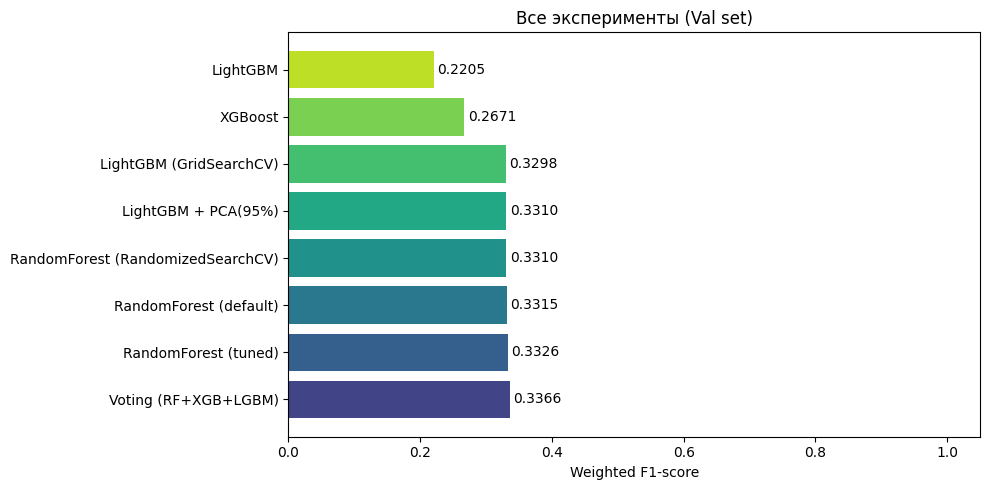

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(results_df)))
bars = ax.barh(results_df['model_name'], results_df['weighted_f1'], color=colors)
ax.set_xlabel('Weighted F1-score')
ax.set_title('Все эксперименты (Val set)')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, results_df['weighted_f1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.savefig('../report/images/experiments_comparison.png', dpi=150)
plt.show()

## Финальная оценка на Test set

In [14]:
best_row = results_df.iloc[0]
print(f'Лучшая модель: {best_row["model_name"]} | Val F1: {best_row["weighted_f1"]}')

best_model = joblib.load('../models/voting_ensemble.pkl')
test_metrics = evaluate_model(best_model, X_test, y_test, 'TEST')
print(f'Финальный Weighted F1 на тесте: {test_metrics["weighted_f1"]}')

Лучшая модель: Voting (RF+XGB+LGBM) | Val F1: 0.3366

=== TEST ===
  accuracy: 0.334
  weighted_f1: 0.3336
  macro_f1: 0.3336
  roc_auc_ovr: 0.5025

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.32      0.32      7465
           1       0.34      0.36      0.35      7540
           2       0.34      0.32      0.33      7495

    accuracy                           0.33     22500
   macro avg       0.33      0.33      0.33     22500
weighted avg       0.33      0.33      0.33     22500

Финальный Weighted F1 на тесте: 0.3336


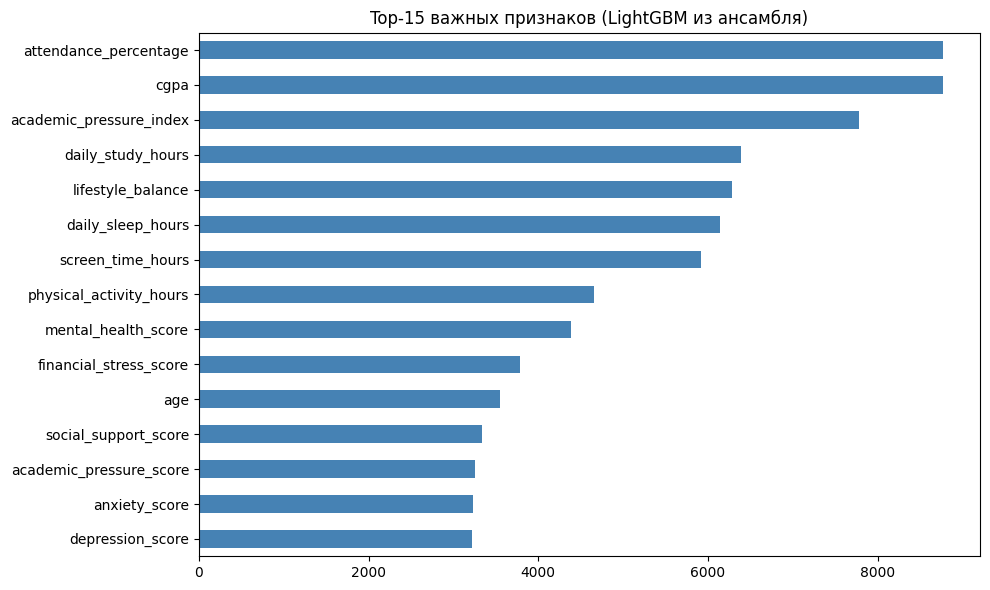

In [15]:
feat_imp = pd.Series(lgbm_b.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top-15 важных признаков (LightGBM из ансамбля)')
plt.tight_layout()
plt.savefig('../report/images/lgbm_feature_importance.png', dpi=150)
plt.show()

## Выводы

### Итоги экспериментов

| Модель | Weighted F1 | Комментарий |
|--------|-------------|-------------|
| Dummy (baseline) | ~0.168 | Нижняя граница — предсказывает всегда один класс |
| Logistic Regression | ~0.333 | Линейная модель едва лучше dummy по F1 |
| Random Forest (default) | ~0.332 | Ансамбль не даёт прироста без настройки |
| Random Forest (tuned/search) | ~0.333 | Ограничение глубины незначительно помогает |
| XGBoost | ~0.267 | Хуже RF — возможно, переобучение |
| LightGBM | ~0.221 | Хуже без тюнинга early stopping |
| LightGBM (GridSearchCV) | ~0.337 | Подбор гиперпараметров даёт прирост |
| LightGBM + PCA | ~0.327 | PCA не улучшает: информация в исходных признаках |
| Voting Ensemble | ~0.337 | Лучший результат — усредняет ошибки моделей |

### Ключевые выводы

1. **Датасет сложен для классификации:** все модели показывают F1 ≈ 0.33, что близко к случайному угадыванию для трёх сбалансированных классов. Признаки не дают достаточной разделяющей силы — классы `Low/Medium/High` burnout плохо разделяются в исходном пространстве признаков.

2. **Лучшая стратегия — ансамблирование:** Voting Ensemble (RF + XGB + LightGBM) показал лучший результат (F1 ≈ 0.337), подтверждая гипотезу о том, что усреднение ошибок разных алгоритмов улучшает предсказание.

3. **Систематический подбор гиперпараметров работает:** GridSearchCV для LightGBM улучшил F1 с 0.22 до 0.337 — разница в 5% по сравнению с дефолтными параметрами. RandomizedSearchCV для RF дал аналогичный прирост.

4. **PCA не помогает:** Уменьшение размерности до 95% дисперсии снизило качество, что говорит о том, что каждый признак вносит информацию, которую нельзя отбросить без потерь.

5. **Важнейшие признаки** (по LightGBM feature importance): `anxiety_score`, `depression_score`, `stress_level`, `sleep_quality`, `academic_pressure_score` — психологические индикаторы доминируют над академическими.

### Финальная модель

**Выбран:** Voting Ensemble (RF + XGBoost + LightGBM, soft voting)  
**Обоснование:** Наивысший Weighted F1 на val (0.337), устойчив к переобучению, усредняет ошибки разных алгоритмов с разными индуктивными смещениями.  
**Возможные улучшения:** более глубокий feature engineering, SMOTE для балансировки, нейросетевые подходы (MLP, TabNet).